# 🎬 Movie Recommendation System
### Content-Based Filtering using NLP + Cosine Similarity

**Dataset:** TMDB 5000 Movies Dataset (Kaggle)  
**Approach:** We build a "tags" column combining genres, keywords, cast, director, and overview — then use cosine similarity to find similar movies.

**ML Concepts Used:**
- Text Vectorization (Bag of Words)
- Cosine Similarity
- NLP preprocessing (stemming, lowercasing)
- Data Merging and Feature Engineering

In [2]:
import numpy as np
import pandas as pd
import ast
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem.porter import PorterStemmer
import nltk
import pickle
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\adity\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
# Load both CSV files
# Note: tmdb_5000_movies.csv has movie details
# tmdb_5000_credits.csv has cast and crew info

movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

print("Movies dataset shape:", movies.shape)
print("Credits dataset shape:", credits.shape)

Movies dataset shape: (4803, 20)
Credits dataset shape: (4803, 4)


In [6]:
# Always start by looking at your data
movies.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


In [8]:
credits.head(2)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [10]:
print("=== MOVIES COLUMNS ===")
print(movies.columns.tolist())
print("\n=== CREDITS COLUMNS ===")
print(credits.columns.tolist())
print("\n=== MOVIES DTYPES ===")
print(movies.dtypes)

=== MOVIES COLUMNS ===
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

=== CREDITS COLUMNS ===
['movie_id', 'title', 'cast', 'crew']

=== MOVIES DTYPES ===
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
v

In [12]:
print("=== MOVIES DATASET STATISTICS ===")
print(f"Total movies: {movies.shape[0]}")
print(f"Total columns: {movies.shape[1]}")
print(f"\nVote average range: {movies['vote_average'].min()} to {movies['vote_average'].max()}")
print(f"Average movie budget: ${movies['budget'].mean():,.0f}")
print(f"\nLanguages in dataset:\n{movies['original_language'].value_counts().head(5)}")

=== MOVIES DATASET STATISTICS ===
Total movies: 4803
Total columns: 20

Vote average range: 0.0 to 10.0
Average movie budget: $29,045,040

Languages in dataset:
original_language
en    4505
fr      70
es      32
zh      27
de      27
Name: count, dtype: int64


In [14]:
print("=== MISSING VALUES IN MOVIES ===")
print(movies.isnull().sum())
print("\n=== MISSING VALUES IN CREDITS ===")
print(credits.isnull().sum())

=== MISSING VALUES IN MOVIES ===
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

=== MISSING VALUES IN CREDITS ===
movie_id    0
title       0
cast        0
crew        0
dtype: int64


In [16]:
# Merge on title column
# credits has 'movie_id' and 'title', movies has 'id' column
credits.rename(columns={'movie_id': 'id'}, inplace=True)

movies = movies.merge(credits, on='id')

print("After merging shape:", movies.shape)
movies[['id', 'title_x', 'genres', 'cast', 'crew']].head(2)

After merging shape: (4803, 23)


,id,title_x,genres,cast,crew
0,19995,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [18]:
# We only need these columns for our recommendation system
movies = movies[['id', 'title_x', 'overview', 'genres', 'keywords', 'cast', 'crew']]
movies.rename(columns={'title_x': 'title'}, inplace=True)

print("Columns selected:", movies.columns.tolist())
movies.head(2)

Columns selected: ['id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']


,id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [20]:
print("Missing values before dropping:")
print(movies.isnull().sum())

movies.dropna(inplace=True)

print(f"\nShape after dropping nulls: {movies.shape}")
print("Missing values after dropping:")
print(movies.isnull().sum())

Missing values before dropping:
id          0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

Shape after dropping nulls: (4800, 7)
Missing values after dropping:
id          0
title       0
overview    0
genres      0
keywords    0
cast        0
crew        0
dtype: int64


In [22]:
# genres and keywords columns contain JSON strings like:
# [{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}]
# We need to extract just the names

def extract_names(obj):
    """Extract 'name' values from a JSON-like string."""
    name_list = []
    for item in ast.literal_eval(obj):
        name_list.append(item['name'])
    return name_list

# Test it
sample = movies['genres'].iloc[0]
print("Before:", sample[:80])
print("After:", extract_names(sample))

Before: [{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name
After: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']


In [24]:
movies['genres'] = movies['genres'].apply(extract_names)
movies['keywords'] = movies['keywords'].apply(extract_names)

print("Genres example:", movies['genres'].iloc[0])
print("Keywords example:", movies['keywords'].iloc[0])

Genres example: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Keywords example: ['culture clash', 'future', 'space war', 'space colony', 'society', 'space travel', 'futuristic', 'romance', 'space', 'alien', 'tribe', 'alien planet', 'cgi', 'marine', 'soldier', 'battle', 'love affair', 'anti war', 'power relations', 'mind and soul', '3d']


In [26]:
def extract_cast(obj):
    """Extract top 3 cast member names only."""
    cast_list = []
    counter = 0
    for item in ast.literal_eval(obj):
        if counter < 3:
            cast_list.append(item['name'])
            counter += 1
        else:
            break
    return cast_list

movies['cast'] = movies['cast'].apply(extract_cast)
print("Cast example:", movies['cast'].iloc[0])

Cast example: ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']


In [28]:
def extract_director(obj):
    """Extract only the director from crew list."""
    for item in ast.literal_eval(obj):
        if item['job'] == 'Director':
            return [item['name']]  # return as list for consistency
    return []

movies['crew'] = movies['crew'].apply(extract_director)
print("Director example:", movies['crew'].iloc[0])

Director example: ['James Cameron']


In [30]:
# Overview is a plain string, convert it to a list of words
movies['overview'] = movies['overview'].apply(lambda x: x.split())

print("Overview example (first 5 words):", movies['overview'].iloc[0][:5])

Overview example (first 5 words): ['In', 'the', '22nd', 'century,', 'a']


In [32]:
# This is important! "Sam Worthington" should be "SamWorthington"
# so it's treated as one token, not two separate words

def remove_spaces(lst):
    """Join multi-word names so they're treated as single tokens."""
    return [item.replace(" ", "") for item in lst]

movies['genres'] = movies['genres'].apply(remove_spaces)
movies['keywords'] = movies['keywords'].apply(remove_spaces)
movies['cast'] = movies['cast'].apply(remove_spaces)
movies['crew'] = movies['crew'].apply(remove_spaces)

print("Genres after removing spaces:", movies['genres'].iloc[0])
print("Cast after removing spaces:", movies['cast'].iloc[0])

Genres after removing spaces: ['Action', 'Adventure', 'Fantasy', 'ScienceFiction']
Cast after removing spaces: ['SamWorthington', 'ZoeSaldana', 'SigourneyWeaver']


In [34]:
# Combine all features into one 'tags' column
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

# Keep only the columns we need
new_df = movies[['id', 'title', 'tags']].copy()

# Convert list to string
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))

# Lowercase everything for consistency
new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())

print("Tags column created!")
new_df.head(3)

Tags column created!


,id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...


In [36]:
# Stemming reduces words to their root form
# Example: "loving", "loved", "loves" → "love"
# This improves matching between similar words

ps = PorterStemmer()

def stem_text(text):
    """Apply stemming to each word in the text."""
    return " ".join([ps.stem(word) for word in text.split()])

new_df['tags'] = new_df['tags'].apply(stem_text)

print("After stemming (example):")
print(new_df['tags'].iloc[0][:200])

After stemming (example):
in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cul


In [37]:
# CountVectorizer converts text into a matrix of word counts
# max_features=5000 means we use only the 5000 most common words
# stop_words='english' removes common words like "the", "is", "and"

cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()

print("Vectors shape:", vectors.shape)
print("Each movie is now represented as a vector of", vectors.shape[1], "features")

Vectors shape: (4800, 5000)
Each movie is now represented as a vector of 5000 features


## Why Cosine Similarity?

Cosine similarity measures the **angle** between two vectors, not their magnitude.

- Two movies with similar word distributions will have vectors pointing in similar directions → **high cosine similarity (close to 1)**
- Two very different movies will have vectors pointing in different directions → **low cosine similarity (close to 0)**

This works better than Euclidean distance for text data because a longer overview shouldn't make a movie seem "further away".

In [43]:
similarity = cosine_similarity(vectors)

print("Similarity matrix shape:", similarity.shape)
print(f"\nThis means we have similarity scores between all {similarity.shape[0]} movies")
print("\nSample similarity scores for first movie (Avatar):")
print(similarity[0][:10])

Similarity matrix shape: (4800, 4800)

This means we have similarity scores between all 4800 movies

Sample similarity scores for first movie (Avatar):
[1.         0.08458258 0.08718573 0.07445808 0.19184046 0.10984369
 0.04078237 0.14870448 0.06003002 0.09802862]


In [45]:
def recommend(movie):
    """
    Given a movie title, return top 5 similar movies.
    
    Steps:
    1. Find the index of the input movie
    2. Get similarity scores with all other movies
    3. Sort by similarity (highest first)
    4. Return top 5 (excluding itself)
    """
    # Check if movie exists
    if movie not in new_df['title'].values:
        print(f"Movie '{movie}' not found in dataset.")
        return
    
    # Get index of the movie
    movie_index = new_df[new_df['title'] == movie].index[0]
    
    # Get similarity scores with all movies, sort descending
    distances = sorted(list(enumerate(similarity[movie_index])), 
                       reverse=True, key=lambda x: x[1])
    
    print(f"\n🎬 Because you liked '{movie}', you might also enjoy:\n")
    for i, (idx, score) in enumerate(distances[1:6], 1):
        print(f"  {i}. {new_df.iloc[idx].title}  (similarity: {score:.3f})")

In [47]:
recommend('Avatar')


🎬 Because you liked 'Avatar', you might also enjoy:

  1. Aliens vs Predator: Requiem  (similarity: 0.291)
  2. Aliens  (similarity: 0.273)
  3. Falcon Rising  (similarity: 0.264)
  4. Independence Day  (similarity: 0.259)
  5. Titan A.E.  (similarity: 0.254)


In [49]:
recommend('The Dark Knight Rises')


🎬 Because you liked 'The Dark Knight Rises', you might also enjoy:

  1. The Dark Knight  (similarity: 0.423)
  2. Batman Returns  (similarity: 0.325)
  3. Batman Forever  (similarity: 0.318)
  4. Batman Begins  (similarity: 0.318)
  5. Batman  (similarity: 0.302)


In [51]:
recommend('Interstellar')


🎬 Because you liked 'Interstellar', you might also enjoy:

  1. Guardians of the Galaxy  (similarity: 0.250)
  2. Silent Running  (similarity: 0.245)
  3. Space Cowboys  (similarity: 0.223)
  4. The Martian  (similarity: 0.216)
  5. Apollo 13  (similarity: 0.216)


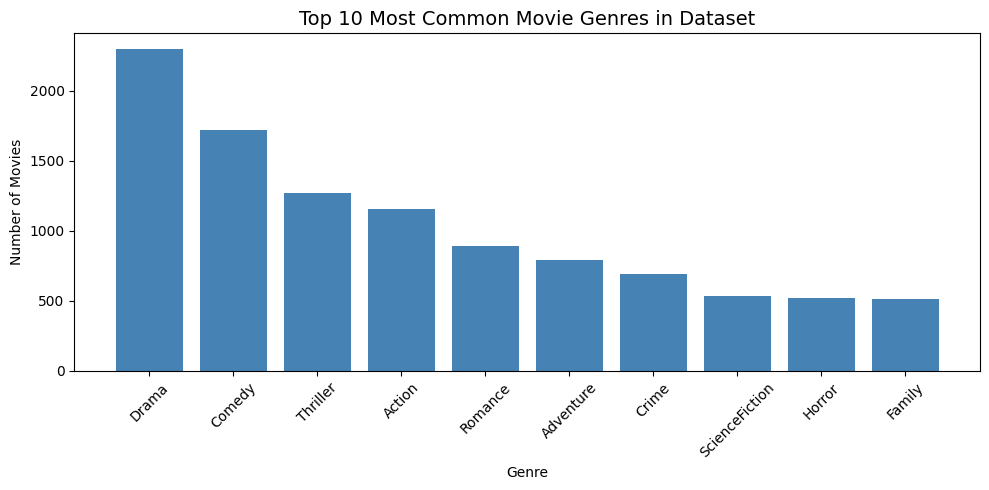

Chart saved as genre_distribution.png


In [53]:
import matplotlib.pyplot as plt
from collections import Counter

# Flatten all genres
all_genres = []
for genre_list in movies['genres']:
    all_genres.extend(genre_list)

genre_counts = Counter(all_genres)
top_genres = dict(sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(10, 5))
plt.bar(top_genres.keys(), top_genres.values(), color='steelblue')
plt.title('Top 10 Most Common Movie Genres in Dataset', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()
print("Chart saved as genre_distribution.png")

In [55]:
import os
os.makedirs('model', exist_ok=True)

# Save the dataframe (we need movie_id for poster fetching)
pickle.dump(new_df, open('model/movie_list.pkl', 'wb'))

# Save the similarity matrix
pickle.dump(similarity, open('model/similarity.pkl', 'wb'))

print("✅ model/movie_list.pkl saved")
print("✅ model/similarity.pkl saved")
print("\nThese files are used by app.py to run the Streamlit app.")

✅ model/movie_list.pkl saved
✅ model/similarity.pkl saved

These files are used by app.py to run the Streamlit app.


## ✅ Project Summary

### What We Built
A **Content-Based Movie Recommendation System** that suggests similar movies based on their content (genres, keywords, cast, director, plot overview).

### ML Workflow Followed
1. **Data Collection** — TMDB 5000 dataset from Kaggle
2. **EDA** — Explored shape, missing values, distributions
3. **Data Cleaning** — Dropped nulls, renamed columns, merged datasets
4. **Feature Engineering** — Extracted genres, keywords, cast, director; built unified 'tags' column
5. **Text Preprocessing** — Lowercasing, stemming, space removal
6. **Vectorization** — Bag of Words with CountVectorizer (5000 features)
7. **Similarity Computation** — Cosine Similarity matrix (4800×4800)
8. **Model Deployment** — Saved with Pickle, deployed via Streamlit

### Key Concepts
- Content-Based Filtering (vs Collaborative Filtering)
- Bag of Words / TF-IDF
- Cosine Similarity
- NLP preprocessing (stemming)
- Feature Engineering from raw JSON columns